In [ ]:
import os
import numpy as np
import torch
import glob
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
from tqdm import tqdm
from torch.utils.data import random_split
from collections import OrderedDict
from sklearn.metrics import confusion_matrix, roc_curve, auc

In [ ]:
NUM_CLASSES = 3
BATCH_SIZE = 64 
LEARNING_RATE = 0.0001
NUM_EPOCHS = 50
IMAGE_SIZE = 224
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
class LensingLayer(nn.Module):
    def __init__(self, img_size=224):
        super(LensingLayer, self).__init__()
        self.img_size = img_size
        x = torch.linspace(-1, 1, img_size)
        y = torch.linspace(-1, 1, img_size)
        grid_x, grid_y = torch.meshgrid(x, y, indexing='ij')
        self.register_buffer('grid', torch.stack((grid_y, grid_x), dim=-1).unsqueeze(0)) 

    def forward(self, x, alpha):
        """
        x: Observed image [B, 3, H, W]
        alpha: Deflection angles predicted by encoder [B, 2]
        """
        batch_size = x.size(0)
        # lens equation: Beta = Theta - Alpha
        shift = alpha.view(batch_size, 1, 1, 2) 
        recon_grid = self.grid.expand(batch_size, -1, -1, -1) - shift
        
        # Resampling the observed image to get the reconstructed source
        source_recon = nn.functional.grid_sample(x, recon_grid, align_corners=True)
        return source_recon


class PINNLensingModel(nn.Module):
    def __init__(self):
        super(PINNLensingModel, self).__init__()
        
        self.parameter_encoder = models.resnet34(weights=None)
        self.parameter_encoder.fc = nn.Linear(self.parameter_encoder.fc.in_features, 2)
        
        
        self.lensing_layer = LensingLayer(img_size=IMAGE_SIZE)
        
        # Final Classifier (EfficientNet-B0)
        # Input is 6 channels (3 observed + 3 reconstructed)
        self.classifier = models.efficientnet_b0(weights=None)
        
        # Adjust first conv layer to accept 6 channels instead of 3
        original_conv = self.classifier.features[0][0]
        self.classifier.features[0][0] = nn.Conv2d(
            6, original_conv.out_channels, 
            kernel_size=original_conv.kernel_size, 
            stride=original_conv.stride, 
            padding=original_conv.padding, 
            bias=False
        )
        
        self.classifier.classifier[1] = nn.Linear(self.classifier.classifier[1].in_features, NUM_CLASSES)

    def forward(self, x):
        # Predict deflection
        alpha = self.parameter_encoder(x)
        # Reconstruct source
        source_recon = self.lensing_layer(x, alpha)
        # Concatenate: [B, 6, 224, 224]
        combined_input = torch.cat((x, source_recon), dim=1)
        
        return self.classifier(combined_input)


class GravitationalLensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        self.samples = []
        for class_name in self.classes:
            class_dir = os.path.join(root_dir, class_name)
            for file_path in glob.glob(os.path.join(class_dir, "*.npy")):
                self.samples.append((file_path, self.class_to_idx[class_name]))
    
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path)
        image = torch.from_numpy(image).float().repeat(3, 1, 1)
        if self.transform: image = self.transform(image)
        return image, label

transform = {
    "train": transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE),
        transforms.RandomRotation(15), transforms.RandomHorizontalFlip(0.5),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ]),
    "val": transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(IMAGE_SIZE),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
}


In [ ]:
data_dir = '/kaggle/input/datasets/adman007/deeplense/dataset'

train_dir = os.path.join(data_dir, 'train')

full_dataset = GravitationalLensingDataset(train_dir, transform=transform['train'])

train_size = int(0.9 * len(full_dataset))


val_size = len(full_dataset) - train_size

train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)


model = PINNLensingModel().to(DEVICE)

model = torch.compile(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

best_acc = 0.0
for epoch in range(NUM_EPOCHS):
    model.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for inputs, labels in pbar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
    
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    val_acc = correct / total
    print(f"Validation Accuracy: {val_acc:.4f}")
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), 'phy_effnet_b0_best.pt')




Epoch 1:   0%|          | 0/422 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
Epoch 1: 100%|██████████| 422/422 [02:55<00:00,  2.41it/s]


Validation Accuracy: 0.3267


Epoch 2: 100%|██████████| 422/422 [01:01<00:00,  6.89it/s]


Validation Accuracy: 0.3413


Epoch 3: 100%|██████████| 422/422 [00:25<00:00, 16.67it/s]


...

Validation Accuracy: 0.8050


Epoch 49: 100%|██████████| 422/422 [00:25<00:00, 16.72it/s]


Validation Accuracy: 0.8980


Epoch 50: 100%|██████████| 422/422 [00:25<00:00, 16.55it/s]


Validation Accuracy: 0.7163


In [ ]:
def evaluate_and_plot(model, loader, class_names):
    model.eval()
    all_probs = []
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
            all_preds.append(preds.cpu().numpy())

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)

    
    cm = confusion_matrix(all_labels, all_preds)
    plot_confusion_matrix(cm, class_names)

    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    
    for i in range(NUM_CLASSES):
        binary_labels = (all_labels == i).astype(int)
        fpr[i], tpr[i], _ = roc_curve(binary_labels, all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    
    plot_roc_curves(fpr, tpr, roc_auc, class_names)

def plot_roc_curves(fpr, tpr, roc_auc, class_names):
    plt.figure(figsize=(10, 8))
    for i in range(NUM_CLASSES):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.5f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


def plot_history(history, num_epochs=NUM_EPOCHS):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss vs. Epoch')
    plt.xlim(0, num_epochs - 1)  # Set x-axis range
    plt.ylim(0, 1)  # Loss should ideally be positive, but limiting to 0-1 depends on the problem
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy vs. Epoch')
    plt.xlim(0, num_epochs - 1)  # Set x-axis range
    plt.ylim(0, 1)  # Accuracy is always between 0 and 1
    
    plt.tight_layout()
    plt.savefig('training_history_1.png')
    plt.show()


def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix_1.png')
    plt.show()

Evaluating: 100%|██████████| 47/47 [00:02<00:00, 23.26it/s]


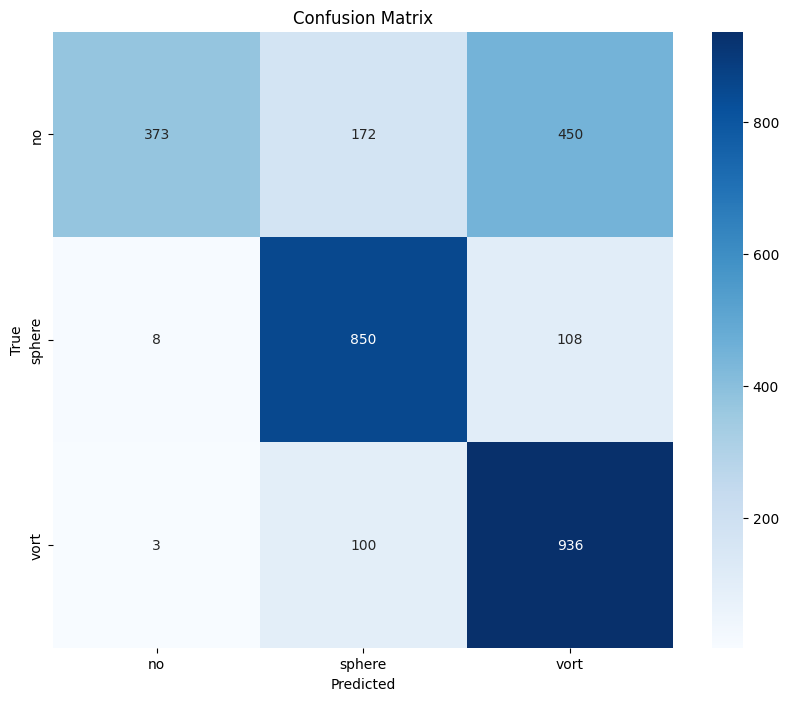

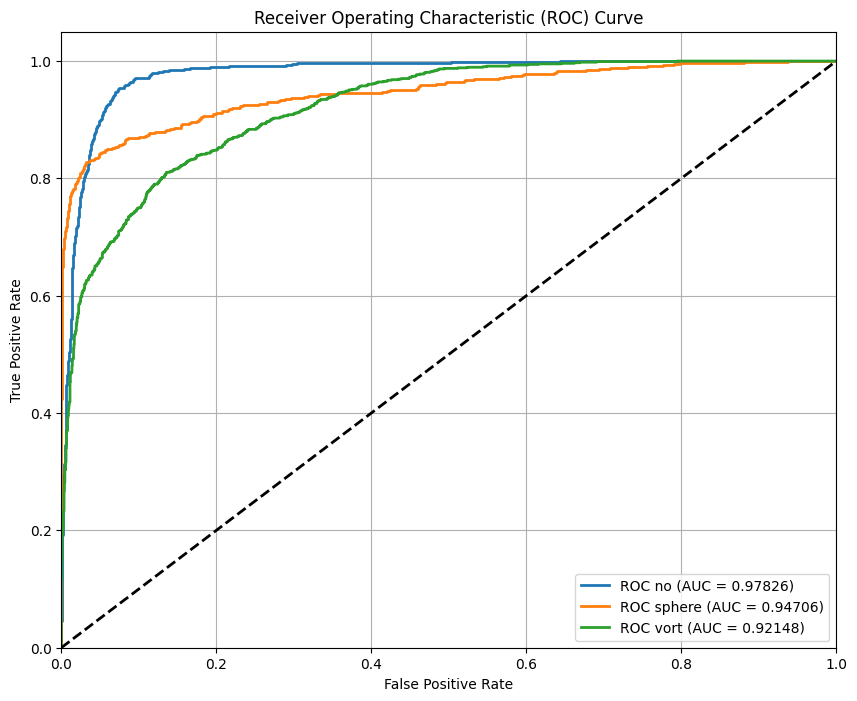

In [7]:
class_names = list(full_dataset.class_to_idx.keys())
evaluate_and_plot(model, val_loader, class_names)

Evaluating: 100%|██████████| 118/118 [01:00<00:00,  1.96it/s]


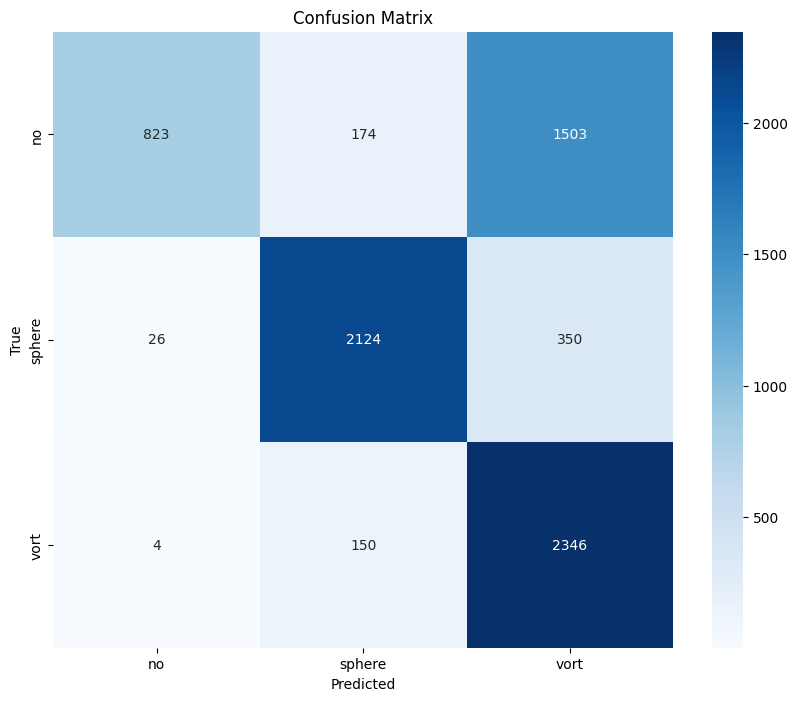

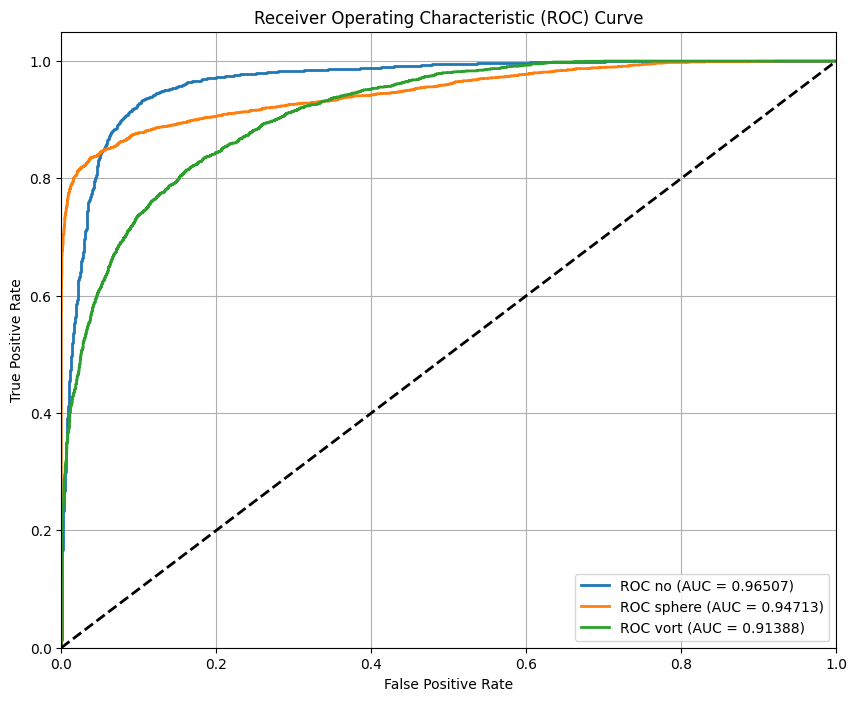

In [ ]:

TEST_DIR = '/kaggle/input/datasets/adman007/deeplense/dataset/val' 

test_dataset = GravitationalLensingDataset(TEST_DIR, transform=transform['val'])
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


evaluate_and_plot(model, test_loader, list(full_dataset.class_to_idx.keys()))